In [5]:
import requests
import os
import re
import time
from dotenv import load_dotenv

import pandas as pd
import matplotlib.pyplot as plt

In [6]:
load_dotenv()

True

#### Scopus API Search

- Scopus api has 2 views, complete (25 results) and standard (200 results)
- 5000 item total result limit without ‘cursor pagination’
- weekly quota 20000
- requests per sec 9 
- view results fields ![view results][https://dev.elsevier.com/sc_search_views.html]

we can query by publishers
```
'PUBLISHER(Wiley) AND TITLE-ABS(poly*)'
```
As of 15 Jun 26:
- For Wiley: 275551 results
- Springer Nature: 20022 results
- Elsevier: 766550 results

using polymer* OR copolymer*
As of 25 Jun 26
- For Wiley: 198739 results
- Springer Nature: 15268 results
- Elsevier: 510466 results

TODO: maybe use the COMPLETE view to retrieve as much abstracts as possible?

In [37]:
publisher = "Elsevier"

url = "https://api.elsevier.com/content/search/scopus"
scopus_api_key = os.getenv("SCOPUS_API_KEY")
query = f'PUBLISHER({publisher}) AND TITLE-ABS-KEY(polymer* OR copolymer*)'
# query = f'PUBLISHER({publisher}) AND TITLE-ABS-KEY(polymer*)'

# need dc:description for abstract
FIELDS = "eid,prism:doi,dc:title,prism:publicationName,dc:publisher,openaccess,openaccessFlag"
# pagination does not need start param
# check cursor:@next for next page, and cursor:"*" for first page
params = {
    "query":   query,
    "field":   FIELDS,
    "start":   0,
    "count":   200,
    "view":    "STANDARD",   
    # "cursor": "*",
}
headers = {
    "X-ELS-APIKey": scopus_api_key,
    "Accept": "application/json"
}

response = requests.get(url, params=params, headers=headers)

assert response.status_code == 200, f"Request failed, ELS Status: {response.headers.get('X-ELS-Status')}"

data = response.json()

In [38]:
data

{'search-results': {'opensearch:totalResults': '510466',
  'opensearch:startIndex': '0',
  'opensearch:itemsPerPage': '200',
  'opensearch:Query': {'@role': 'request',
   '@searchTerms': 'PUBLISHER(Elsevier) AND TITLE-ABS-KEY(polymer* OR copolymer*)',
   '@startPage': '0'},
  'link': [{'@_fa': 'true',
    '@ref': 'self',
    '@href': 'https://api.elsevier.com/content/search/scopus?start=0&count=200&query=PUBLISHER%28Elsevier%29+AND+TITLE-ABS-KEY%28polymer*+OR+copolymer*%29&field=eid%2Cprism%3Adoi%2Cdc%3Atitle%2Cprism%3ApublicationName%2Cdc%3Apublisher%2Copenaccess%2CopenaccessFlag&view=STANDARD',
    '@type': 'application/json'},
   {'@_fa': 'true',
    '@ref': 'first',
    '@href': 'https://api.elsevier.com/content/search/scopus?start=0&count=200&query=PUBLISHER%28Elsevier%29+AND+TITLE-ABS-KEY%28polymer*+OR+copolymer*%29&field=eid%2Cprism%3Adoi%2Cdc%3Atitle%2Cprism%3ApublicationName%2Cdc%3Apublisher%2Copenaccess%2CopenaccessFlag&view=STANDARD',
    '@type': 'application/json'},
   {'@

In [6]:
def fetch_scopus_year(
    publisher: str,
    pubyear: int,
    count: int = 200
) -> list[dict]:
    """Fetches papers from Scopus for a given publisher and publication year.

    Args:
        publisher (str): The name of the publisher to filter by.
        pubyear (int): The publication year to filter by.
        count (int, optional): The number of results to fetch per request. Defaults to 200.
        query_term (str, optional): The search term to use in the query. Defaults to "poly*".

    Returns:
        list[dict]: A list of dictionaries containing paper information.
    """
    url = "https://api.elsevier.com/content/search/scopus"
    scopus_api_key = os.getenv("SCOPUS_API_KEY")
    query = f'PUBLISHER({publisher}) AND TITLE-ABS(poly*) AND PUBYEAR < {pubyear}'

    # need dc:description for abstract
    FIELDS = "eid,prism:doi,dc:title,prism:publicationName,dc:publisher,openaccess,openaccessFlag"
    # pagination does not need start param
    # check cursor:@next for next page, and cursor:"*" for first page
    params = {
        "query":   query,
        "field":   FIELDS,
        "start":   0,
        "count":   200,
        "view":    "STANDARD",   
        # "cursor": "*",
    }
    headers = {
        "X-ELS-APIKey": scopus_api_key,
        "Accept": "application/json"
    }

    response = requests.get(url, params=params, headers=headers)

    assert response.status_code == 200, f"Request failed, ELS Status: {response.headers.get('X-ELS-Status')}"

    data = response.json()

    entries = data.get("search-results", {}).get("entry", [])

    records = []

    for e in entries:
        records.append({
            "eid": e.get("eid"),
            "doi": e.get("prism:doi"),
            "title": e.get("dc:title"),
            "journal": e.get("prism:publicationName"),
            "publisher": e.get("dc:publisher") or publisher,
            "open_access": e.get("openaccess"),
            "open_access_flag": e.get("openaccessFlag"),
        })

    if not records:
        print(f"No records found for publisher: {publisher}, year: {pubyear}")

    if len(records) < count:
        print(f"Only {len(records)} records found for publisher: {publisher}, year: {pubyear}")

    return records

In [21]:
publisher = "Elsevier"
years = [2026, 2024, 2022, 2020, 2018]

all_records = []

for year in years:
    records = fetch_scopus_year(
        publisher=publisher,
        pubyear=year,
        count=200
    )

    all_records.extend(records)

    time.sleep(0.2)  # Sleep to respect API rate limits

df = pd.DataFrame(all_records)

# Optional deduplication, useful if Scopus returns overlaps
df = df.drop_duplicates(subset=["eid"], keep="first").reset_index(drop=True)

print(f"Total records fetched: {len(df)}")

Total records fetched: 1000


In [22]:
df

,eid,doi,title,journal,publisher,open_access,open_access_flag
0,2-s2.0-105014756884,10.1016/j.seppur.2025.134917,β–Cyclodextrin polymerization for selective se...,Separation and Purification Technology,Elsevier,0,False
1,2-s2.0-105015360119,10.1016/j.seppur.2025.135139,Hierarchically porous polyamidoxime/ZIF-8 hybr...,Separation and Purification Technology,Elsevier,0,False
2,2-s2.0-105009836797,10.1016/j.dam.2025.06.063,Computing the forcing spectrum of outerplanar ...,Discrete Applied Mathematics,Elsevier,1,True
3,2-s2.0-105014911783,10.1016/j.seppur.2025.134886,Polyethyleneimine/amino acid salt thin-film-na...,Separation and Purification Technology,Elsevier,0,False
4,2-s2.0-105014529987,10.1016/j.seppur.2025.134918,Synergistic engineering of PEG-modified biomas...,Separation and Purification Technology,Elsevier,0,False
...,...,...,...,...,...,...,...
995,2-s2.0-85041994216,10.1016/j.electacta.2017.12.004,Electrochemical determination of luteolin usin...,Electrochimica Acta,Elsevier,0,False
996,2-s2.0-85041013742,10.1016/j.electacta.2017.11.185,Capacity Fading Mechanism in Lithium-Sulfur Ba...,Electrochimica Acta,Elsevier,0,False
997,2-s2.0-85035316380,10.1016/j.electacta.2017.11.133,Superior capacitive properties of polyaniline ...,Electrochimica Acta,Elsevier,0,False
998,2-s2.0-85034993468,10.1016/j.polymer.2017.11.045,Theoretical study on the reaction of maleic an...,Polymer,Elsevier,0,False


In [23]:
output_path = os.path.join("..", "data", f"{publisher}_papers.csv")

# df.to_csv(
#     output_path,
#     sep="\t",
#     index=False,
#     encoding="utf-8",
# )

At the moment we have extracted 1000 articles each from 3 publishers. For full extraction I need to implement cursor pagination.

In [28]:
papers = ["elsevier_papers.csv", "springer_nature_papers.csv", "wiley_papers.csv"]
dfs = []
for paper in papers:
    path = os.path.join("..", "data", paper)
    df = pd.read_csv(path, sep="\t")
    dfs.append(df)
    print(f"{paper}: {len(df)} records")

df = pd.concat(dfs, ignore_index=True)

elsevier_papers.csv: 1000 records
springer_nature_papers.csv: 1000 records
wiley_papers.csv: 1000 records


In [29]:
df.head()

,eid,doi,title,journal,publisher,open_access,open_access_flag
0,2-s2.0-105014756884,10.1016/j.seppur.2025.134917,β–Cyclodextrin polymerization for selective se...,Separation and Purification Technology,Elsevier,0,False
1,2-s2.0-105015360119,10.1016/j.seppur.2025.135139,Hierarchically porous polyamidoxime/ZIF-8 hybr...,Separation and Purification Technology,Elsevier,0,False
2,2-s2.0-105009836797,10.1016/j.dam.2025.06.063,Computing the forcing spectrum of outerplanar ...,Discrete Applied Mathematics,Elsevier,1,True
3,2-s2.0-105014911783,10.1016/j.seppur.2025.134886,Polyethyleneimine/amino acid salt thin-film-na...,Separation and Purification Technology,Elsevier,0,False
4,2-s2.0-105014529987,10.1016/j.seppur.2025.134918,Synergistic engineering of PEG-modified biomas...,Separation and Purification Technology,Elsevier,0,False


In [32]:
print(f"OA papers: {len(df[df['open_access_flag'] == True])} of {len(df)}")

OA papers: 1133 of 3000


In [36]:
unique_journals_per_publisher = (
    df.groupby("publisher")["journal"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="unique_journal_count")
)

print(unique_journals_per_publisher)

         publisher  unique_journal_count
0  Springer Nature                   168
1         Elsevier                    56
2            Wiley                    56


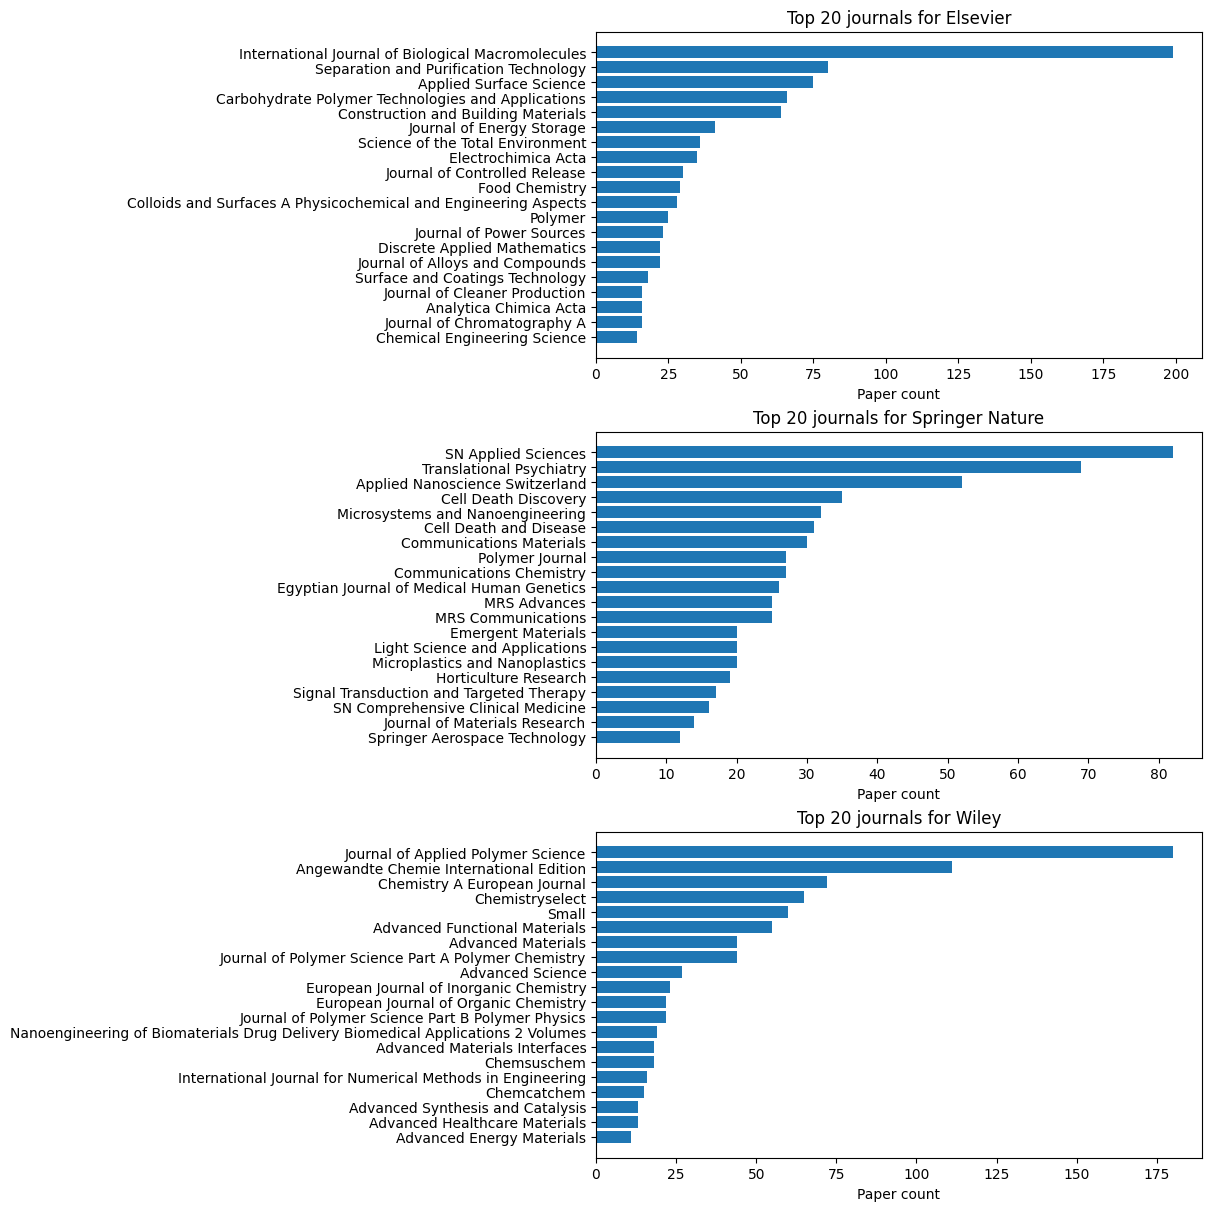

In [39]:
journal_dist = (
    df.groupby(["publisher", "journal"])
    .size()
    .reset_index(name="paper_count")
    .sort_values(["publisher", "paper_count"], ascending=[True, False])
)

top_n = 20
top_journals = journal_dist.groupby("publisher", as_index=False).head(top_n)

publishers = top_journals["publisher"].unique()
fig, axes = plt.subplots(len(publishers), 1, figsize=(12, 4 * len(publishers)), constrained_layout=True)

if len(publishers) == 1:
    axes = [axes]

for ax, pub in zip(axes, publishers):
    subset = top_journals[top_journals["publisher"] == pub].sort_values("paper_count")
    ax.barh(subset["journal"], subset["paper_count"])
    ax.set_title(f"Top {top_n} journals for {pub}")
    ax.set_xlabel("Paper count")

plt.show()

Get abstracts

In [51]:
df["abstract"] = "Not Found"
df.head()

,eid,doi,title,journal,publisher,open_access,open_access_flag,abstract
0,2-s2.0-105014756884,10.1016/j.seppur.2025.134917,β–Cyclodextrin polymerization for selective se...,Separation and Purification Technology,Elsevier,0,False,Not Found
1,2-s2.0-105015360119,10.1016/j.seppur.2025.135139,Hierarchically porous polyamidoxime/ZIF-8 hybr...,Separation and Purification Technology,Elsevier,0,False,Not Found
2,2-s2.0-105009836797,10.1016/j.dam.2025.06.063,Computing the forcing spectrum of outerplanar ...,Discrete Applied Mathematics,Elsevier,1,True,Not Found
3,2-s2.0-105014911783,10.1016/j.seppur.2025.134886,Polyethyleneimine/amino acid salt thin-film-na...,Separation and Purification Technology,Elsevier,0,False,Not Found
4,2-s2.0-105014529987,10.1016/j.seppur.2025.134918,Synergistic engineering of PEG-modified biomas...,Separation and Purification Technology,Elsevier,0,False,Not Found


In [85]:
from difflib import SequenceMatcher

def normalize_title(title: str) -> str:
    title = title.lower()

    # remove punctuation
    title = re.sub(r"[^\w\s]", " ", title)

    # collapse whitespace
    title = re.sub(r"\s+", " ", title)

    return title.strip()

def title_match(
    title1: str,
    title2: str,
    threshold: float = 0.90,
) -> bool:
    t1 = normalize_title(title1)
    t2 = normalize_title(title2)

    score = SequenceMatcher(None, t1, t2).ratio()

    return score >= threshold

Need to add some keywords extraction here.

In [ ]:
def get_crossref_abstract(
    doi: str | None,
    title: str | None,
    mailto: str | None = None,
    timeout: int = 30,
) -> str | None:
    """
        get
    """
    doi = str(doi).strip()

    mailto = "kevinge@chalmers.se"
    headers = {
        "User-Agent": f"abstract-fetcher/0.1 (mailto:{mailto})",
    }

    url = f"https://api.crossref.org/works/{doi}"
    response = requests.get(
        url.format(doi=doi),
        headers=headers,
        timeout=timeout,
    )

    response.raise_for_status()

    data = response.json()

    title_list = data.get("message", {}).get("title", [])
    crossref_title = title_list[0] if title_list else None
    safe_flag = False
    if crossref_title:
        if title_match(title, crossref_title):
            safe_flag = True
        else:
            print(f"[Warning]: Title Mismatch for doi: {doi}")
            print(f"Title: {title}")
            print(f"crossref: {crossref_title}")

    raw_abstract = data.get("message", {}).get("abstract")

    if not raw_abstract:
        return None, None

    # Strip JATS XML tags (e.g. <jats:p>, <jats:title>) and collapse whitespace
    # Remove <jats:title>Abstract</jats:title>
    clean_abstract = re.sub(
        r"<jats:title[^>]*>.*?</jats:title>",
        " ",
        raw_abstract,
        flags=re.I | re.S,
    )
    clean_abstract = re.sub(r"<[^>]+>", " ", clean_abstract)
    clean_abstract = re.sub(r"\s+", " ", clean_abstract).strip()

    return clean_abstract, safe_flag

In [ ]:
for idx, row in df.iterrows():

    current_abstract = row["abstract"]

    # Skip rows that already have an abstract
    if (
        pd.notna(current_abstract)
        and str(current_abstract).strip()
        and str(current_abstract).strip().lower() != "not found"
    ):
        continue

    doi = row["doi"]
    title = row["title"]

    if pd.isna(doi):
        print(f"[CHECK]: doi not in dataframe at index {idx}")
        continue

    time.sleep(0.1)  # be nice to Crossref

    try:
        abstract, safe_flag = get_crossref_abstract(
            doi=doi,
            title=title,
            mailto = "kevinge@chalmers.se"
        )

    except Exception as e:
        print(
            f"Crossref failed | DOI={doi} | "
            f"TITLE={title[:80]} | ERROR={e}"
        )
        continue

    if not abstract:
        continue

    if not safe_flag:
        continue

    df.at[idx, "abstract"] = abstract

    print("[INFO]: Abstract found")
    if idx % 100 == 0 and idx != 0:
        print(f"[INFO]: currently at idx {idx}")

[Warning]: Title Mismatch for doi: 10.1016/j.catena.2025.109504
Title: Mendeley Data
rossref: Skeletal and sedimentary structures in yardang caverns in the Mars analog, Qaidam Basin: origin and implication
Crossref failed | DOI=10.1016/j.est.2025.119087 | TITLE=Ce-V2O5/MBene composite as a multifunctional catalyst for synergistic polysulfid | ERROR=404 Client Error: Not Found for url: https://api.crossref.org/works/10.1016/j.est.2025.119087
[Warning]: Title Mismatch for doi: 10.1016/j.dam.2021.08.032
Title: Finding densest k-connected subgraphs
rossref: Finding densest <mml:math xmlns:mml="http://www.w3.org/1998/Math/MathML" display="inline" id="d1e349" altimg="si11.svg"><mml:mi>k</mml:mi></mml:math>-connected subgraphs
[Warning]: Title Mismatch for doi: 10.1016/j.dam.2021.09.009
Title: Reducing the domination number of (P3+kP2)-free graphs via one edge contraction
rossref: Reducing the domination number of <mml:math xmlns:mml="http://www.w3.org/1998/Math/MathML" display="inline" id="d

In [104]:
summary = (
    df.assign(
        abstract_found=lambda x: (
            x["abstract"].notna()
            & (x["abstract"] != "Not Found")
            & (x["abstract"].str.strip() != "")
        )
    )
    .groupby("publisher")
    .agg(
        total_papers=("publisher", "size"),
        abstracts_found=("abstract_found", "sum"),
    )
)

summary["retrieval_rate"] = (
    100 * summary["abstracts_found"] / summary["total_papers"]
).round(1)

print(summary)

                 total_papers  abstracts_found  retrieval_rate
publisher                                                     
Elsevier                 1000                0             0.0
Springer Nature          1000              448            44.8
Wiley                    1000              915            91.5


In [ ]:
output_path = os.path.join("..", "data", f"papers_post_crossref.csv")

# df.to_csv(
#     output_path,
#     sep="\t",
#     index=False,
#     encoding="utf-8",
# )

Use Scopus

In [107]:
output_path = os.path.join("..", "data", f"papers_post_crossref.csv")
df = pd.read_csv(
    output_path, sep="\t"
)

In [108]:
df.head()

,eid,doi,title,journal,publisher,open_access,open_access_flag,abstract
0,2-s2.0-105014756884,10.1016/j.seppur.2025.134917,β–Cyclodextrin polymerization for selective se...,Separation and Purification Technology,Elsevier,0,False,Not Found
1,2-s2.0-105015360119,10.1016/j.seppur.2025.135139,Hierarchically porous polyamidoxime/ZIF-8 hybr...,Separation and Purification Technology,Elsevier,0,False,Not Found
2,2-s2.0-105009836797,10.1016/j.dam.2025.06.063,Computing the forcing spectrum of outerplanar ...,Discrete Applied Mathematics,Elsevier,1,True,Not Found
3,2-s2.0-105014911783,10.1016/j.seppur.2025.134886,Polyethyleneimine/amino acid salt thin-film-na...,Separation and Purification Technology,Elsevier,0,False,Not Found
4,2-s2.0-105014529987,10.1016/j.seppur.2025.134918,Synergistic engineering of PEG-modified biomas...,Separation and Purification Technology,Elsevier,0,False,Not Found


In [ ]:
from pybliometrics.scopus import AbstractRetrieval

# TODOs: we need some sort of keyword extraction here
def get_scopus_abstract(
    doi: str | None,
) -> str | None:

    if not doi:
        return None

    doi = str(doi).strip()

    try:
        record = AbstractRetrieval(
            doi,
            id_type="doi",
            view="META_ABS",
        )

        # Prefer abstract
        abstract = record.abstract

        # Fallback to description if abstract missing
        if not abstract:
            abstract = getattr(record, "description", None)

        if not abstract:
            print(
                f"No abstract/description found for DOI: {doi}"
            )
            return None

        abstract = " ".join(str(abstract).split())

        return abstract

    except Exception as e:
        print(
            f"Scopus AbstractRetrieval failed | DOI={doi} | "
            f"ERROR={type(e).__name__}: {e}"
        )
        return None

In [132]:
for idx, row in df.iterrows():
    if idx % 100 == 0 and idx != 0:
        print(f"[INFO]: currently at idx {idx}")

    current_abstract = row["abstract"]

    # Skip rows that already have an abstract
    if (
        pd.notna(current_abstract)
        and str(current_abstract).strip()
        and str(current_abstract).strip().lower() != "not found"
    ):
        continue

    doi = row["doi"]

    if pd.isna(doi):
        print(f"[CHECK]: doi not in dataframe at index {idx}")
        continue

    abstract = get_scopus_abstract(
        doi=doi
    )
    time.sleep(0.2)  # respect api rate limits

    if not abstract:
        continue

    df.at[idx, "abstract"] = abstract

    print("[INFO]: Abstract found")

[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abstract found
[INFO]: Abs

In [133]:
summary = (
    df.assign(
        abstract_found=lambda x: (
            x["abstract"].notna()
            & (x["abstract"] != "Not Found")
            & (x["abstract"].str.strip() != "")
        )
    )
    .groupby("publisher")
    .agg(
        total_papers=("publisher", "size"),
        abstracts_found=("abstract_found", "sum"),
    )
)

summary["retrieval_rate"] = (
    100 * summary["abstracts_found"] / summary["total_papers"]
).round(1)

print(summary)

                 total_papers  abstracts_found  retrieval_rate
publisher                                                     
Elsevier                 1000              996            99.6
Springer Nature          1000              987            98.7
Wiley                    1000              995            99.5


In [ ]:
# output_path = os.path.join("..", "data", f"papers_post_scopus.csv")

# df.to_csv(
#     output_path,
#     sep="\t",
#     index=False,
#     encoding="utf-8",
# )

In [106]:
# Publisher TDMs

Building a classifier

In [ ]:
import os
from typing import Optional

from pydantic import BaseModel, Field, ConfigDict
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

from langchain_core.output_parsers import PydanticOutputParser


class PolymerSynthesisClassification(BaseModel):
    model_config = ConfigDict(extra="ignore")

    is_experimental_polymer_synthesis: bool = Field(
        description=(
            "True if the paper reports experimental synthesis, preparation, "
            "fabrication, modification, or degradation of a polymer/material by "
            "the authors in this study. False for reviews, purely computational "
            "papers, characterization-only papers, application-only papers, "
            "biological studies without polymer synthesis, or papers where the "
            "polymer is only purchased/used."
        )
    )


SYSTEM_PROMPT = """
You are a scientific paper classifier for polymer synthesis datasets.

Classify whether the given paper is relevant for an experimental polymer synthesis extraction pipeline.

Return true ONLY if the title and abstract indicate that the authors experimentally synthesized, prepared, fabricated, modified, functionalized, degraded, crosslinked, polymerized, copolymerized, grafted, or otherwise made a polymer/material in this study.

Return false if the paper is:
- a review, perspective, survey, book chapter, editorial, or commentary
- purely computational, theoretical, modeling, simulation, or data-mining
- only about characterization/testing of an existing polymer
- only about applications of a purchased/commercial polymer
- only about biological/medical/environmental testing with no polymer synthesis
- only about monomer synthesis without polymer synthesis
- only about small molecules, catalysts, membranes, adsorbents, or composites where no polymer is synthesized/prepared by the authors
- unclear from the title and abstract

Important:
- Polymer synthesis papers often mention polymerization, copolymerization, grafting, crosslinking, curing, RAFT, ATRP, ROMP, ring-opening polymerization, anionic polymerization, condensation polymerization, or preparation of polymer networks.
- Characterization such as NMR, GPC/SEC, DSC, DMA, TGA, FTIR, mechanical testing, or morphology may support relevance, but characterization alone is not enough.
- Be conservative. If experimental polymer synthesis by the authors is not clear, return false.
"""


USER_PROMPT = """
Title:
{title}

Abstract:
{abstract}

Format instructions:
{format_instructions}
"""

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_API_BASE = os.getenv("OPENROUTER_API_BASE", "https://openrouter.ai/api/v1")


llm = ChatOpenAI(
    # model="openai/gpt-4o-mini",  # change to any OpenRouter model you prefer
    # model="openai/gpt-oss-120b:free",
    api_key=OPENROUTER_API_KEY,
    base_url=OPENROUTER_API_BASE,
    temperature=0,
)

# classifier = llm.with_structured_output(PolymerSynthesisClassification)

parser = PydanticOutputParser(
    pydantic_object=PolymerSynthesisClassification
)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", SYSTEM_PROMPT),
        ("user", USER_PROMPT),
    ]
)
classification_chain = prompt | llm | parser

In [190]:
def classify_paper(
    title: str,
    abstract: str | None = None,
) -> bool:
    """
    Return True if the paper appears to contain experimental polymer synthesis
    performed by the authors, otherwise False.
    """

    try:
        result = classification_chain.invoke(
            {
                "title": title or "",
                "abstract": abstract or "",
                "format_instructions": parser.get_format_instructions(),
            }
        )

        return bool(
            result.is_experimental_polymer_synthesis
        )

    except Exception as e:
        print(
            f"Classification failed | "
            f"TITLE={title[:100] if title else 'None'} | "
            f"ERROR={type(e).__name__}: {e}"
        )

        return False

In [ ]:
labels = []

for idx, row in df.iterrows():
    if idx % 100 == 0 and idx != 0:
        print(f"[INFO]: currently at idx {idx}")

    title = row.get("title")
    abstract = row.get("abstract")

    # Missing title -> automatically False
    if not title or not str(title).strip():
        labels.append(False)
        continue

    # Missing abstract -> automatically False
    if (
        abstract is None
        or pd.isna(abstract)
        or str(abstract).strip() == ""
        or str(abstract).strip().lower() == "not found"
    ):
        labels.append(False)
        continue

    result = classify_paper(title, abstract)

    labels.append(result)

    time.sleep(3.8)

There are some structured output parsing errors. Reduced a lot when adding format instructions into the user prompt. But still very few errors. But that can be accomodated by instructor I think. But with instructor we can't do think steps

In [172]:
assert len(df) == len(labels)
# df["is_experimental_polymer_synthesis"] = labels
df["polymer_synthesis_oss_120"] = labels

In [ ]:
# output_path = os.path.join("..", "data", f"papers_classified_w_oss.csv")

# df.to_csv(
#     output_path,
#     sep="\t",
#     index=False,
#     encoding="utf-8",
# )

In [ ]:
from sklearn.metrics import cohen_kappa_score

agreement = (
    df["is_experimental_polymer_synthesis"]
    == df["polymer_synthesis_oss_120"]
).mean()

print(f"Agreement: {agreement:.2%}")

kappa = cohen_kappa_score(
    df["is_experimental_polymer_synthesis"],
    df["polymer_synthesis_oss_120"]
)

print(f"Cohen's κ = {kappa:.3f}")

Agreement: 88.67%
Cohen's κ = 0.749


In [179]:
pd.crosstab(
    df["is_experimental_polymer_synthesis"],
    df["polymer_synthesis_oss_120"],
    rownames=["GPT4"],
    colnames=["OSS"],
)

OSS,False,True
GPT4,,
False,1793,169
True,171,867


In [197]:
disagreement = df[
    df["is_experimental_polymer_synthesis"] != df["polymer_synthesis_oss_120"]
]

print(len(disagreement))

display_df = disagreement[
    [
        "title",
        "abstract",
        "is_experimental_polymer_synthesis",
        "polymer_synthesis_oss_120",
    ]
].copy()

display_df.columns = ["title", "abstract", "gpt", "oss"]

display(
    display_df.head().style.set_properties(
        subset=["title"],
        **{
            "white-space": "pre-wrap",
            "max-width": "300px",
        }
    ).set_properties(
        subset=["abstract"],
        **{
            "white-space": "pre-wrap",
            "max-width": "800px",
        }
    )
)

340


,title,abstract,gpt,oss
33,Enhancing CO2 transport across Pebax-based mixed-matrix membranes using a sterically bulky aromatic diacid,"In this study, the sterically bulky 4,5-bis(9H-carbazol-9-yl)phthalic acid (2CzPA) was employed as a filler for poly(amide-b-ethylene oxide) (Pebax) to fabricate Pebax/2CzPA mixed-matrix membranes (MMMs), with the aim of enhancing CO2 gas permeability across the membranes. The two CO2-philic carboxylic acid (–COOH) functional groups in the 2CzPA filler interact with incoming (permeating) CO2 molecules, enhancing their solubility within the polymer matrix. Moreover, the two sterically bulky 1,2-bicarbazole moieties disrupt the chain packing of the soft poly(ethylene oxide) (PEO) segments in Pebax, leading to improved gas diffusivity. IR analysis confirmed the presence of hydrogen bonding interactions between the carboxylic acid groups of 2CzPA and the amide groups of Pebax, which contribute to enhance the thermal and mechanical properties of the membranes. With the addition of 1 wt% 2CzPA, the CO2 permeability of the Pebax membrane increased from 164.70 to 227.51 Barrer, without compromising the CO2/N2 (∼48.20) and CO2/CH4 (∼15.60) selectivities. The best-performing membrane, Pebax/2CzPA-1.0, also exhibited excellent anti-aging performance over a period of 100 days.",True,False
36,A novel and sustainable basalt fabric-based photo-electrothermal evaporator with Janus hydrophilic gradient structure for all-weather actual brackish water purification,"To address global freshwater scarcity, developing a sustainable and efficient brackish/high salinity water desalination technology is crucial. Solar-driven interfacial evaporation (SIE) systems typically consist of a water-absorbing layer drawing water via capillary action to the interface and a photothermal conversion layer absorbing sunlight to heat the interface. Researchers have focused primarily on designing various photothermal materials to enhance heat generation and evaporation efficiency, while they often overlook the need for all-weather functionality, limiting further advancement of SIE systems. This study introduces a novel basalt fabric-based photo-electrothermal interfacial evaporator for all-weather efficient desalination, integrating photothermal and electrothermal effects to enhance evaporation rates and reduce reliance on sunlight. The basalt fabric is functionalized with polydopamine, carbon nanotubes, and polypyrrole to improve its photothermal properties, and stainless steel mesh 304 is used as an electrothermal layer. Under simulated sunlight (1 sun) and 1.5 V in the laboratory, the evaporation rate of actual brackish water can reach 4.43 kg m−2 h−1; under real sunlight and 1.5 V outdoors, the evaporation rate can reach up to 6.37 kg m−2 h−1. Additionally, due to the well-designed multilayer structure with Janus hydrophilicity gradient distribution, the evaporator exhibits excellent salt resistance and long-term stability, maintaining a daytime evaporation rate above 2.17 kg m−2 h−1 during 120-hour continuous operation without any intervention. The purified water meets the drinking water standards set by the WHO, with significant reductions in ion concentrations and chemical oxygen demand. This study provides a promising approach for efficient and sustainable brackish water purification, offering potential applications in water-scarce regions.",False,True
69,Harvesting Fe & Ca-rich coal fly ash for the preparation of water treatment chemicals,"The consumption of coal as a primary energy source has resulted in the production of significant amounts of industrial waste, particularly coal fly ash (CFA). Substantial accumulation of CFA leads to environmental issues, including dust generation and groundwater contamination. CFA is mainly composed of silica and aluminum oxide, along with various other elements, such as iron, calcium, sodium, and titanium. The resource utilization of CFA represents a crucial strategy for mitigating the pol

In [183]:
disagreement["abstract"].iloc[0]

'In this study, the sterically bulky 4,5-bis(9H-carbazol-9-yl)phthalic acid (2CzPA) was employed as a filler for poly(amide-b-ethylene oxide) (Pebax) to fabricate Pebax/2CzPA mixed-matrix membranes (MMMs), with the aim of enhancing CO2 gas permeability across the membranes. The two CO2-philic carboxylic acid (–COOH) functional groups in the 2CzPA filler interact with incoming (permeating) CO2 molecules, enhancing their solubility within the polymer matrix. Moreover, the two sterically bulky 1,2-bicarbazole moieties disrupt the chain packing of the soft poly(ethylene oxide) (PEO) segments in Pebax, leading to improved gas diffusivity. IR analysis confirmed the presence of hydrogen bonding interactions between the carboxylic acid groups of 2CzPA and the amide groups of Pebax, which contribute to enhance the thermal and mechanical properties of the membranes. With the addition of 1 wt% 2CzPA, the CO2 permeability of the Pebax membrane increased from 164.70 to 227.51 Barrer, without compro

In [ ]:
# disagreement.to_csv(
#     os.path.join("..", "data", f"classifier_disagreements.csv"),
#     sep="\t",
#     index=False,
# )

In [8]:
summary = (
    df.groupby("publisher")["is_experimental_polymer_synthesis"]
      .agg(
          total_papers="count",
          synthesis_papers="sum",
      )
)

summary["fraction"] = (
    summary["synthesis_papers"]
    / summary["total_papers"]
).round(3)

summary["percent"] = (
    100 * summary["fraction"]
).round(1)

print(summary)

                 total_papers  synthesis_papers  fraction  percent
publisher                                                         
Elsevier                 1000               386     0.386     38.6
Springer Nature          1000               197     0.197     19.7
Wiley                    1000               455     0.455     45.5


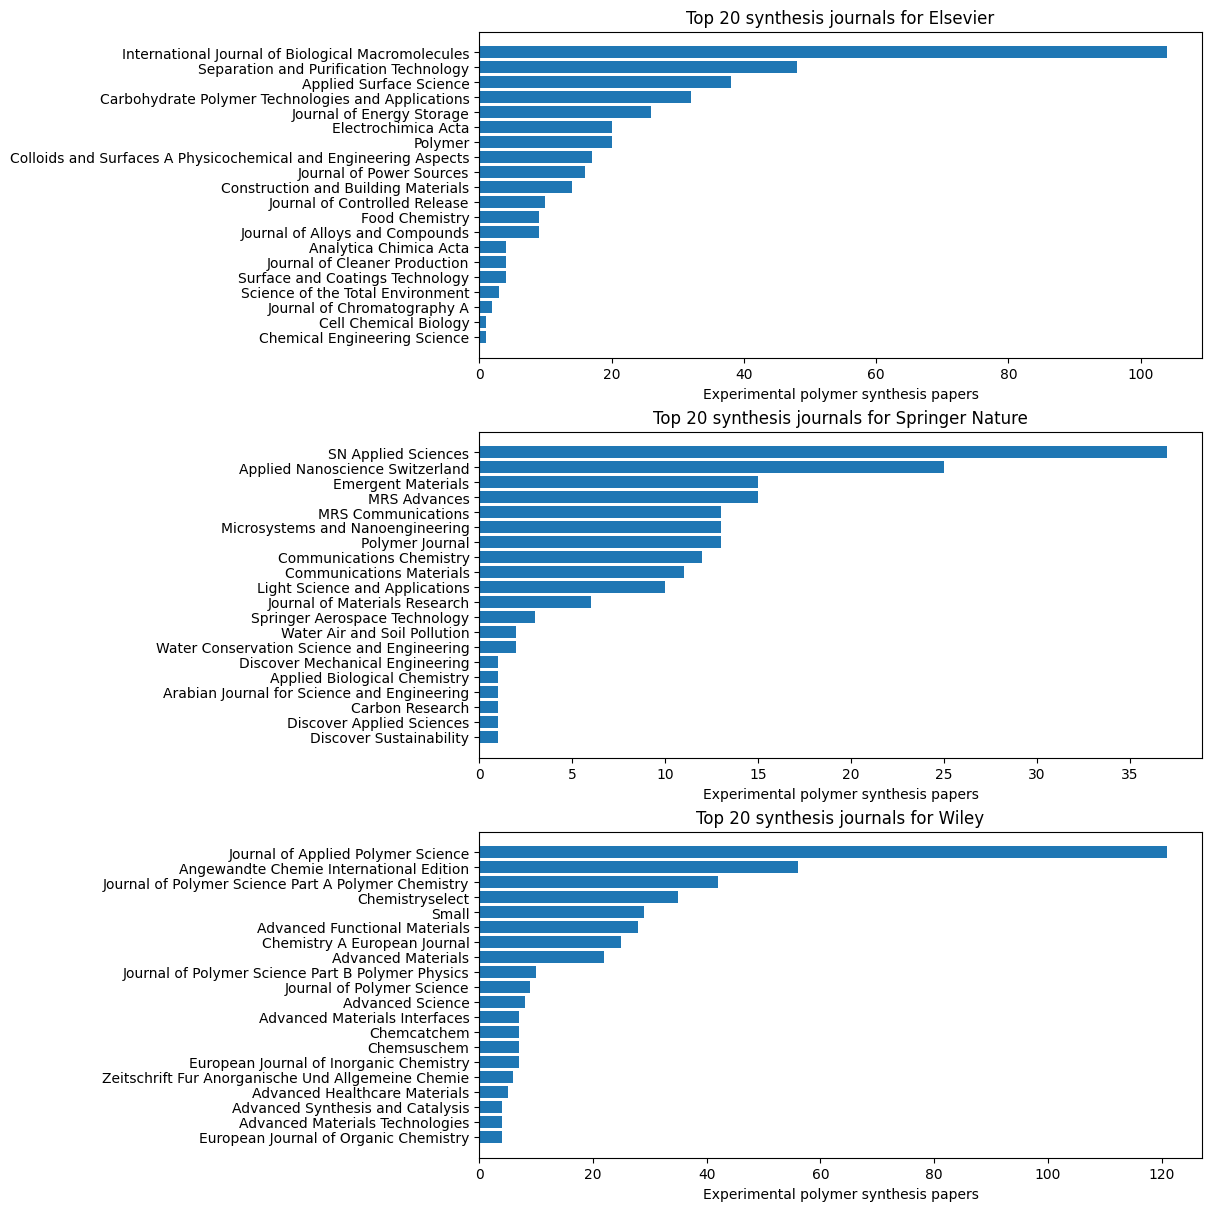

In [9]:
synthesis_df = df[
    df["is_experimental_polymer_synthesis"]
]
journal_dist = (
    synthesis_df.groupby(["publisher", "journal"])
    .size()
    .reset_index(name="paper_count")
    .sort_values(
        ["publisher", "paper_count"],
        ascending=[True, False],
    )
)

top_n = 20

top_journals = (
    journal_dist.groupby(
        "publisher",
        as_index=False,
    )
    .head(top_n)
)

publishers = top_journals["publisher"].unique()

fig, axes = plt.subplots(
    len(publishers),
    1,
    figsize=(12, 4 * len(publishers)),
    constrained_layout=True,
)

if len(publishers) == 1:
    axes = [axes]

for ax, pub in zip(axes, publishers):

    subset = (
        top_journals[
            top_journals["publisher"] == pub
        ]
        .sort_values("paper_count")
    )

    ax.barh(
        subset["journal"],
        subset["paper_count"],
    )

    ax.set_title(
        f"Top {top_n} synthesis journals for {pub}"
    )

    ax.set_xlabel(
        "Experimental polymer synthesis papers"
    )

plt.show()

In [10]:
synthesis_df["journal"].value_counts().head(10)

journal
Journal of Applied Polymer Science                     121
International Journal of Biological Macromolecules     104
Angewandte Chemie International Edition                 56
Separation and Purification Technology                  48
Journal of Polymer Science Part A Polymer Chemistry     42
Applied Surface Science                                 38
SN Applied Sciences                                     37
Chemistryselect                                         35
Carbohydrate Polymer Technologies and Applications      32
Small                                                   29
Name: count, dtype: int64

In [11]:
top_10_journals = (
    synthesis_df["journal"]
    .value_counts()
    .head(5)
    .index
)

random_papers = (
    synthesis_df[
        synthesis_df["journal"].isin(top_10_journals)
    ]
    .groupby("journal", group_keys=False)
    .sample(2, random_state=12)
)

random_papers[
    [
        "journal",
        "title",
        "doi",
        "is_experimental_polymer_synthesis",
        "polymer_synthesis_oss_120"
    ]
]

,journal,title,doi,is_experimental_polymer_synthesis,polymer_synthesis_oss_120
2915,Angewandte Chemie International Edition,Room-Temperature-Phosphorescence-Based Dissolv...,10.1002/anie.201708606,True,True
2822,Angewandte Chemie International Edition,Radical Copolymerization of Vinyl Ethers and C...,10.1002/anie.201707043,True,True
350,International Journal of Biological Macromolec...,Enhancing polyhydroxyalkanoate production in C...,10.1016/j.ijbiomac.2023.127439,True,True
205,International Journal of Biological Macromolec...,A self-healing hydrogel wound dressing based o...,10.1016/j.ijbiomac.2023.127189,True,True
2876,Journal of Applied Polymer Science,Solid polymer electrolyte based on waterborne ...,10.1002/app.45554,True,True
2767,Journal of Applied Polymer Science,Chitosan-based double network hydrogels with s...,10.1002/app.48247,True,True
2750,Journal of Polymer Science Part A Polymer Chem...,Degradable cellulose-based polymer brushes wit...,10.1002/pola.29481,True,True
2736,Journal of Polymer Science Part A Polymer Chem...,Cationic polymerization of n-hexyloxyallene by...,10.1002/pola.29489,True,True
73,Separation and Purification Technology,Selective CO2-to-CO photocatalytic conversion ...,10.1016/j.seppur.2025.134981,True,True
49,Separation and Purification Technology,Sandwich-structured nanofiltration membrane fo...,10.1016/j.seppur.2025.135099,True,True


In [23]:
journal_name = "Polymer"

journal_papers = synthesis_df[
    synthesis_df["journal"].str.lower() == journal_name.lower()
][
    [
        "title",
        "doi",
    ]
].copy()

journal_papers
display(
    journal_papers.style.set_properties(
        subset=["title"],
        **{
            "white-space": "pre-wrap",
            "max-width": "1000px",
        }
    )
)

,title,doi
796,Ionic liquid copolymerized polyurethane membranes for pervaporation separation of benzene/cyclohexane mixtures,10.1016/j.polymer.2019.121948
798,Bamboo-like nanostructures prepared using template-based wetting methods: Molecular arrangements of polyimide and carbon tubes in cylindrical nanopores,10.1016/j.polymer.2019.121979
799,Preparation and properties of polystyrene/silica fibres flexible thermal insulation materials by centrifugal spinning,10.1016/j.polymer.2019.121964
957,Unilamellar polyion complex vesicles (PICsomes) with tunable permeabilities for macromolecular solutes with different shapes and sizes,10.1016/j.polymer.2017.10.062
960,"AIE-active florescent polymers: The design, synthesis and the cell imaging application",10.1016/j.polymer.2017.11.030
962,Systematic comparison of single-walled carbon nanotube/poly(vinyl acetate) graft-to reactions,10.1016/j.polymer.2017.10.047
966,Development of complete silica thin films based on functional hyperbranched polyalkoxysiloxanes,10.1016/j.polymer.2017.11.019
970,Redox-active poly(ionic liquid)-engineered Ag nanoparticle-decorated ZnO nanoflower heterostructure: A reusable composite catalyst for photopolymerization into high-molecular-weight polymers,10.1016/j.polymer.2017.11.033
975,Efficient benzodithiophene and thienopyrroledione containing random polymers as components for organic solar cells,10.1016/j.polymer.2017.11.024
976,Synthesis and characterization of hyperbranched polyimides from a novel B'B2-type triamine with tert-butyl side group,10.1016/j.polymer.2017.11.029


In [ ]:
# randomly select a paper from the top 10 for screenshots
# This costed us 0.35 dollars
# We now also have prediction gpt oss 120b, the inference time of this model is very slow. Somewhere around 8 hours for 3000 datapoints

TDM full text retrival

In [ ]:
# Something to think about is word cloud on keywords. check if we can get keywords for classified and non classified models.

# Tried for Springer Nature papers only. total faliure. No keywords present

In [258]:
springer_df = df[
    (df["publisher"] == "Springer Nature")
    & (
        (df["open_access_flag"] == True)
        | (df["open_access_flag"].astype(str).str.lower() == "true")
        | (df["open_access"].astype(str) == "1")
    )
].copy()

springer_df["springer_subjects"] = None
springer_df["springer_keywords"] = None

print(
    f"Found {len(springer_df)} Springer Nature OA papers"
)

Found 665 Springer Nature OA papers


In [ ]:
springer_df["springer_subjects"] = None
springer_df["springer_keywords"] = None

SPRINGER_NATURE_API_KEY = os.getenv("SPRINGER_NATURE_API_KEY")

for idx, row in springer_df.iterrows():

    if idx % 100 == 0 and idx != 0:
        print(f"[INFO] Currently at idx {idx}")

    doi = row.get("doi")

    if pd.isna(doi) or not str(doi).strip():
        print(f"[CHECK] Missing DOI at idx={idx}")
        continue

    doi = str(doi).strip()

    url = (
        "https://api.springernature.com/openaccess/json"
        f"?api_key={SPRINGER_NATURE_API_KEY}"
        f"&s=1&p=10&q=(doi:\"{doi}\")"
    )

    try:
        response = requests.get(
            url,
            timeout=30,
        )

        response.raise_for_status()

        data = response.json()

    except Exception as e:
        print(
            f"[ERROR] Springer API failed | "
            f"idx={idx} | DOI={doi} | {e}"
        )
        continue

    records = data.get("records", [])

    if not records:
        continue

    record = records[0]

    subjects = record.get("subjects", []) or []

    keywords = (
        record.get("keywords")
        or record.get("keyword")
        or []
    )

    if isinstance(keywords, str):
        keywords = [keywords]

    if isinstance(keywords, dict):
        keywords = list(keywords.values())

    print(keywords)

    springer_df.at[idx, "springer_subjects"] = "; ".join(subjects)
    springer_df.at[idx, "springer_keywords"] = "; ".join(keywords)

    time.sleep(1)

In [268]:
subject_df = springer_df[
    springer_df["springer_subjects"].notna()
    & (springer_df["springer_subjects"].str.strip() != "")
].copy()

subject_df["subject"] = (
    subject_df["springer_subjects"]
    .str.split(";")
)

subject_df = subject_df.explode("subject")

subject_df["subject"] = subject_df["subject"].str.strip()

subject_df = subject_df[
    subject_df["subject"].notna()
    & (subject_df["subject"] != "")
]
subject_counts = (
    subject_df
    .groupby(["is_experimental_polymer_synthesis", "subject"])
    .size()
    .reset_index(name="count")
)
top_false = (
    subject_counts[
        subject_counts["is_experimental_polymer_synthesis"] == False
    ]
    .sort_values("count", ascending=False)
    .head(10)
)
top_true = (
    subject_counts[
        subject_counts["is_experimental_polymer_synthesis"] == True
    ]
    .sort_values("count", ascending=False)
    .head(10)
)

In [269]:
top_true

,is_experimental_polymer_synthesis,subject,count
197,True,Materials Science,30
187,True,Engineering,20
198,True,"Materials Science, general",18
203,True,Nanotechnology,17
189,True,"Engineering, general",17
204,True,Nanotechnology and Microengineering,16
179,True,"Chemistry/Food Science, general",16
200,True,Membrane Biology,15
202,True,Nanochemistry,15
178,True,Chemistry,14


In [ ]:
# after this we need to do other sources. PMC and so on (if time is not available we skip this and move forward)